In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



df1 = pd.read_csv(r"C:\Users\laami\Downloads\order_line\order_info.csv")
df2 = pd.read_csv(r"C:\Users\laami\Downloads\order_line\order_line.csv")

mrg=pd.merge(df1,df2,on='Order ID', how='inner')
print(mrg.head())

   Order ID Customer ID Warehouse ID  Customer Age Customer Gender  \
0         1     CUST966        WH004            65          Female   
1         1     CUST966        WH004            65          Female   
2         1     CUST966        WH004            65          Female   
3         1     CUST966        WH004            65          Female   
4         1     CUST966        WH004            65          Female   

         Date   Product ID   SKU ID           Category  Quantity  \
0  2023-03-04  Product_110  SKU_291  Health & Wellness         4   
1  2023-03-04  Product_142  SKU_005  Health & Wellness         5   
2  2023-03-04  Product_197  SKU_151        Electronics         2   
3  2023-03-04  Product_195  SKU_945  Fashion & Apparel         1   
4  2023-03-04  Product_110  SKU_333  Health & Wellness         5   

   Price per Unit  
0          527.06  
1          847.13  
2          214.60  
3          513.50  
4          436.15  


In [3]:
unique_id=mrg['Customer ID'].unique()


['CUST966' 'CUST952' 'CUST987' 'CUST415' 'CUST160' 'CUST162' 'CUST737'
 'CUST948' 'CUST116' 'CUST298' 'CUST622' 'CUST148' 'CUST409' 'CUST426'
 'CUST377' 'CUST625' 'CUST429' 'CUST442' 'CUST453' 'CUST509' 'CUST816'
 'CUST296' 'CUST872' 'CUST915' 'CUST919' 'CUST902' 'CUST341' 'CUST362'
 'CUST123' 'CUST394' 'CUST353' 'CUST539' 'CUST203' 'CUST051' 'CUST986'
 'CUST324' 'CUST501' 'CUST135' 'CUST332' 'CUST256' 'CUST478' 'CUST466'
 'CUST554' 'CUST122' 'CUST474' 'CUST076' 'CUST873' 'CUST357' 'CUST234'
 'CUST019' 'CUST315' 'CUST784' 'CUST165' 'CUST263' 'CUST776' 'CUST087'
 'CUST563' 'CUST771' 'CUST727' 'CUST016' 'CUST385' 'CUST118' 'CUST780'
 'CUST023' 'CUST103' 'CUST679' 'CUST175' 'CUST594' 'CUST342' 'CUST367'
 'CUST449' 'CUST806' 'CUST414' 'CUST877' 'CUST658' 'CUST117' 'CUST859'
 'CUST171' 'CUST316' 'CUST244' 'CUST399' 'CUST886' 'CUST558' 'CUST958'
 'CUST480' 'CUST655' 'CUST722' 'CUST151' 'CUST956' 'CUST010' 'CUST835'
 'CUST272' 'CUST493' 'CUST852' 'CUST086' 'CUST927' 'CUST071' 'CUST959'
 'CUST

In [4]:
count_unique=mrg['Customer ID'].nunique()
print(count_unique)

1000


In [5]:
unique_customers_df = mrg[['Customer ID']].drop_duplicates()
print(unique_customers_df.head())

   Customer ID
0      CUST966
9      CUST952
10     CUST987
15     CUST415
23     CUST160


In [6]:
df=mrg.copy()
df['order_value'] = df['Quantity'] * df['Price per Unit']
print(df.head())

   Order ID Customer ID Warehouse ID  Customer Age Customer Gender  \
0         1     CUST966        WH004            65          Female   
1         1     CUST966        WH004            65          Female   
2         1     CUST966        WH004            65          Female   
3         1     CUST966        WH004            65          Female   
4         1     CUST966        WH004            65          Female   

         Date   Product ID   SKU ID           Category  Quantity  \
0  2023-03-04  Product_110  SKU_291  Health & Wellness         4   
1  2023-03-04  Product_142  SKU_005  Health & Wellness         5   
2  2023-03-04  Product_197  SKU_151        Electronics         2   
3  2023-03-04  Product_195  SKU_945  Fashion & Apparel         1   
4  2023-03-04  Product_110  SKU_333  Health & Wellness         5   

   Price per Unit  order_value  
0          527.06      2108.24  
1          847.13      4235.65  
2          214.60       429.20  
3          513.50       513.50  
4    

In [7]:
average_order_value = df.groupby('Customer ID')['order_value'].mean()

print(average_order_value)

Customer ID
CUST001    1348.963721
CUST002    1353.771034
CUST003    1187.813929
CUST004    1382.176667
CUST005    1526.746667
              ...     
CUST995    1498.250769
CUST996    1559.702000
CUST997    1521.431957
CUST998    1255.387241
CUST999    1442.328182
Name: order_value, Length: 1000, dtype: float64


In [8]:
# Group by Customer ID and calculate average order_value
avg_order_value_per_customer = df.groupby('Customer ID', as_index=False)['order_value'].mean()

# Rename the column
avg_order_value_per_customer.rename(columns={'order_value': 'Average Order Value'}, inplace=True)

print(avg_order_value_per_customer.head())

  Customer ID  Average Order Value
0     CUST001          1348.963721
1     CUST002          1353.771034
2     CUST003          1187.813929
3     CUST004          1382.176667
4     CUST005          1526.746667


In [9]:
print(avg_order_value_per_customer.tail())

    Customer ID  Average Order Value
995     CUST995          1498.250769
996     CUST996          1559.702000
997     CUST997          1521.431957
998     CUST998          1255.387241
999     CUST999          1442.328182


In [10]:
#  Group by Customer ID and calculate average order_value
avg_order_value = df.groupby('Customer ID', as_index=False)['order_value'].mean()
avg_order_value.rename(columns={'order_value': 'Average Order Value'}, inplace=True)

#  Get unique age and gender per customer (assuming they are constant per customer)
customer_info = df[['Customer ID', 'Customer Age', 'Customer Gender']].drop_duplicates(subset='Customer ID')

merged_df = pd.merge(avg_order_value, customer_info, on='Customer ID', how='left')

print(merged_df.head())

  Customer ID  Average Order Value  Customer Age Customer Gender
0     CUST001          1348.963721            24          Female
1     CUST002          1353.771034            35          Female
2     CUST003          1187.813929            26            Male
3     CUST004          1382.176667            25            Male
4     CUST005          1526.746667            29          Female


In [11]:
merged_df = merged_df.drop(columns=['Customer ID'])

print(merged_df.head())

   Average Order Value  Customer Age Customer Gender
0          1348.963721            24          Female
1          1353.771034            35          Female
2          1187.813929            26            Male
3          1382.176667            25            Male
4          1526.746667            29          Female


In [12]:
grouped_avg = merged_df.groupby(['Customer Age', 'Customer Gender'], as_index=False)['Average Order Value'].mean()

print(grouped_avg.head())

   Customer Age Customer Gender  Average Order Value
0            18          Female          1314.141212
1            18            Male          1477.796747
2            19          Female          1415.048526
3            19            Male          1354.856382
4            20          Female          1445.373151


In [13]:
print(grouped_avg.tail())

    Customer Age Customer Gender  Average Order Value
91            63            Male          1422.551004
92            64          Female          1534.687687
93            64            Male          1491.927786
94            65          Female          1324.915474
95            65            Male          1504.950776


In [22]:
from sklearn.cluster import KMeans, Birch, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pickle

merged_df['Customer Gender'] = merged_df['Customer Gender'].map({'Male': 0, 'Female': 1})
features = merged_df[['Customer Age', 'Customer Gender', 'Average Order Value']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42).fit(scaled_features)
birch = Birch(n_clusters=4).fit(scaled_features)
mini_kmeans = MiniBatchKMeans(n_clusters=4, random_state=42).fit(scaled_features)
gmm = GaussianMixture(n_components=4, random_state=42).fit(scaled_features)
knn = KNeighborsClassifier(n_neighbors=3).fit(scaled_features, kmeans.labels_)

models = {
    "KMeans": kmeans,
    "Birch": birch,
    "MiniBatchKMeans": mini_kmeans,
    "GaussianMixture": gmm,
    "KNeighborsClassifier": knn
}

results = {}
for name, model in models.items():
    labels = model.predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    results[name] = {"model": model, "score": score}

best_model_name = max(results, key=lambda x: results[x]['score'])
best_model = results[best_model_name]['model']
print(f" Best Clustering Model: {best_model_name} (Silhouette Score: {results[best_model_name]['score']:.2f})")

merged_df['Cluster'] = best_model.predict(scaled_features)
with open("best_clustering_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)





 Best Clustering Model: GaussianMixture (Silhouette Score: 0.37)


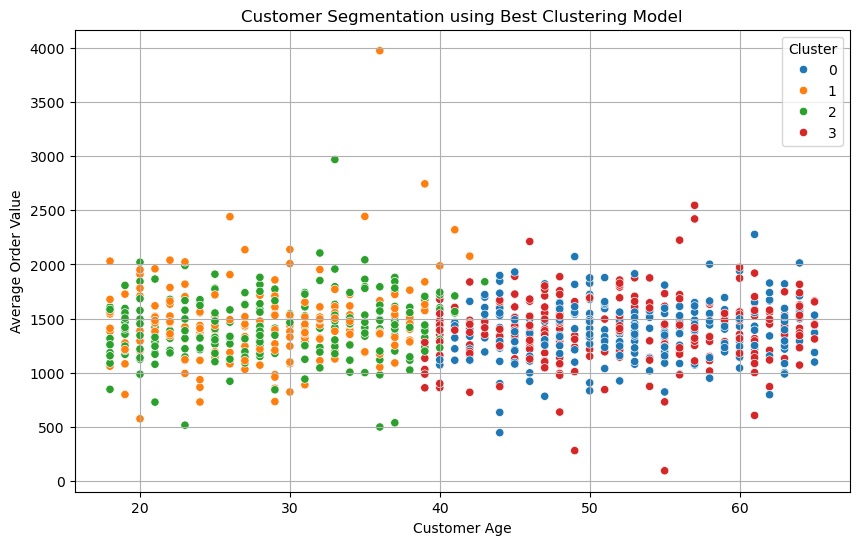

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_df, x='Customer Age', y='Average Order Value', hue='Cluster', palette='tab10')
plt.title("Customer Segmentation using Best Clustering Model")
plt.xlabel("Customer Age")
plt.ylabel("Average Order Value")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


In [24]:
import pandas as pd
import pickle

def predict_new_customer_cluster():
    try:
        age = int(input("Enter Customer Age: "))
        gender = input("Enter Gender (Male/Female): ").strip().lower()
        aov = float(input("Enter Average Order Value (₹): "))
        if gender not in ['male', 'female']:
            print(" Please enter 'Male' or 'Female'")
            return
        gender_encoded = 0 if gender == 'female' else 1
        input_df = pd.DataFrame([[age, gender_encoded, aov]],
                                columns=["Customer Age", "Customer Gender", "Average Order Value"])

        with open("scaler.pkl", "rb") as f:
            scaler = pickle.load(f)
        with open("best_clustering_model.pkl", "rb") as f:
            model = pickle.load(f)

        scaled_input = scaler.transform(input_df)
        cluster = model.predict(scaled_input)[0]
        print(f"\n Predicted Cluster: {cluster}")

    except Exception as e:
        print(" Error:", e)

predict_new_customer_cluster()


Enter Customer Age:  24
Enter Gender (Male/Female):  male
Enter Average Order Value (₹):  1436



 Predicted Cluster: 2
